# Toxic Comment Detection Main Training Pipeline
**Model:** SGD Classifier  
**Features:** Word TF-IDF + Engineering Features (Oangsa + Ploy)


## 1. Imports

In [27]:
# !pip install scipy

In [28]:
# !pip install scikit-learn

In [29]:
# !pip install contractions

In [30]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)

from optuna.samplers import TPESampler

from toxic_pipeline import (
    ALL_ENGINEERED_FEATURE_COLUMNS,
    WORD_TFIDF_CONFIG as PIPELINE_WORD_TFIDF_CONFIG,
    build_all_engineered_features,
    clean_text,
    protect_non_toxic_negations,
)

print('All imports OK')


All imports OK


## 1.5 Constants


In [31]:
DATA_PATH = '../data/train.csv'
LABEL_COLUMNS_TO_DROP = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

SEARCH_RANDOM_STATE = 42
SEARCH_TEST_SIZE = 0.20
SEARCH_CV_SPLITS = 3
OPTUNA_TRIALS_PER_MODEL = 20
SEARCH_CLASS_WEIGHTS = ['balanced', {0:1, 1:3}]

WORD_TFIDF_CONFIG = dict(PIPELINE_WORD_TFIDF_CONFIG)
SCALER_CONFIG = {'with_mean': False}
SGD_FIXED_MAX_ITER = 500
LR_FIXED_MAX_ITER = 500
LR_FINAL_MAX_ITER = 2000

SGD_OPTUNA_MODEL_BASE_CONFIG = {
    'loss': 'modified_huber',
    'max_iter': SGD_FIXED_MAX_ITER,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}
LR_OPTUNA_MODEL_BASE_CONFIG = {
    'solver': 'liblinear',
    'max_iter': LR_FIXED_MAX_ITER,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}
LR_FINAL_MODEL_CONFIG = {
    'solver': 'liblinear',
    'max_iter': LR_FINAL_MAX_ITER,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}
SGD_OPTUNA_ALPHA_RANGE = (1e-5, 1e-3)
SGD_OPTUNA_L1_RATIO_RANGE = (0.05, 0.95)
SGD_OPTUNA_TOL_RANGE = (1e-5, 1e-3)
LR_OPTUNA_C_RANGE = (3e-2, 3.0)
LR_OPTUNA_TOL_RANGE = (1e-5, 1e-3)

OPTUNA_WORD_VECTORIZER_PATH = 'optuna_word_vectorizer.pkl'
OPTUNA_SCALER_PATH = 'optuna_scaler.pkl'
OPTUNA_BEST_MODEL_PATH = 'optuna_best_model.pkl'


## 2. Load & Clean Data

In [32]:
df = pd.read_csv(DATA_PATH)

# keep only toxic label
df = df.drop(columns=LABEL_COLUMNS_TO_DROP)

df['raw_text'] = df['comment_text'].fillna('').astype(str)
df['protected_text'] = df['raw_text'].apply(protect_non_toxic_negations)
df['clean_text'] = df['protected_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text'])
df = df.reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(df['toxic'].value_counts())


Dataset shape: (158194, 6)
toxic
0    143038
1     15156
Name: count, dtype: int64


## 3. Feature Engineering

In [33]:
engineered_df = pd.concat(
    [build_all_engineered_features(text) for text in df['raw_text']],
    ignore_index=True,
)
df[ALL_ENGINEERED_FEATURE_COLUMNS] = engineered_df

print('Pattern helpers aligned with toxic_pipeline.py')


Pattern helpers aligned with toxic_pipeline.py


In [34]:
df.head(3)


,id,comment_text,toxic,raw_text,protected_text,clean_text,Character Count,Word Count,Exclamation Count,Profanity Count,...,Repeated Character Pattern Count,Average Word Length,Uppercase Ratio,Question Mark Count,Repeated Punctuation Count,Identity-group Term Count,URL Count,Negation Count,Non-toxic Negation Pattern Count,Short/Unclear Without Toxic Signal Flag
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,Explanation\nWhy the edits made under my usern...,Explanation Why the edits made under my userna...,explanation why the edits made under my userna...,264,46,0,0,...,0,4.478261,0.083744,1,0,0,0,2,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,D'aww! He matches this background colour I'm s...,D'aww! He matches this background colour I am ...,d aww he matches this background colour i am s...,112,16,1,0,...,0,4.625000,0.109589,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,"Hey man, I'm really not trying to edit war. It...","Hey man, I am really not trying to edit war. I...",hey man i am really not trying to edit war it ...,233,44,0,0,...,0,4.272727,0.021505,0,0,1,0,1,0,0


## 4. Train / Test Split

In [35]:
ENG_FEATURE_COLS = ALL_ENGINEERED_FEATURE_COLUMNS.copy()

X_clean = df['clean_text']
X_eng = df[ENG_FEATURE_COLS]
y = df['toxic']

(
    X_clean_train, X_clean_test,
    X_eng_train, X_eng_test,
    y_train, y_test
) = train_test_split(
    X_clean, X_eng, y,
    test_size=SEARCH_TEST_SIZE,
    random_state=SEARCH_RANDOM_STATE,
    stratify=y,
)

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Toxic ratio (train): {y_train.mean():.3f}')


Train: 126,555  |  Test: 31,639
Toxic ratio (train): 0.096


## 5. Vectorize Text

In [36]:
word_vec = TfidfVectorizer(**WORD_TFIDF_CONFIG)
X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test = word_vec.transform(X_clean_test)

print(f'Word TF-IDF : {X_word_train.shape}')


Word TF-IDF : (126555, 10000)


In [37]:
scaler = StandardScaler(**SCALER_CONFIG)
X_eng_train_scaled = scaler.fit_transform(X_eng_train.values)
X_eng_test_scaled = scaler.transform(X_eng_test.values)

X_train = hstack([X_word_train, csr_matrix(X_eng_train_scaled)], format='csr')
X_test = hstack([X_word_test, csr_matrix(X_eng_test_scaled)], format='csr')

print(f'Final feature matrix (train): {X_train.shape}')
print(f'Final feature matrix (test) : {X_test.shape}')


Final feature matrix (train): (126555, 10016)
Final feature matrix (test) : (31639, 10016)


5.5 Automated parameter tuning with Optuna

In [38]:
import optuna
print(f'optuna version: {optuna.__version__}')


optuna version: 4.8.0


In [39]:

search_cv = StratifiedKFold(
    n_splits=SEARCH_CV_SPLITS,
    shuffle=True,
    random_state=SEARCH_RANDOM_STATE,
)

def suggest_class_weight(trial, prefix):
    idx = trial.suggest_int(f'{prefix}_class_weight_idx', 0, len(SEARCH_CLASS_WEIGHTS) - 1)
    return SEARCH_CLASS_WEIGHTS[idx]


def objective_sgd(trial):
    model = SGDClassifier(
        **SGD_OPTUNA_MODEL_BASE_CONFIG,
        alpha=trial.suggest_float('alpha', SGD_OPTUNA_ALPHA_RANGE[0], SGD_OPTUNA_ALPHA_RANGE[1], log=True),
        penalty=trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        l1_ratio=trial.suggest_float('l1_ratio', SGD_OPTUNA_L1_RATIO_RANGE[0], SGD_OPTUNA_L1_RATIO_RANGE[1]),
        class_weight=suggest_class_weight(trial, 'sgd'),
        tol=trial.suggest_float('tol', SGD_OPTUNA_TOL_RANGE[0], SGD_OPTUNA_TOL_RANGE[1], log=True),
    )
    return cross_val_score(model, X_train, y_train, cv=search_cv, scoring='f1', n_jobs=-1).mean()


def objective_lr(trial):
    model = LogisticRegression(
        **LR_OPTUNA_MODEL_BASE_CONFIG,
        penalty=trial.suggest_categorical('penalty', ['l1', 'l2']),
        C=trial.suggest_float('C', LR_OPTUNA_C_RANGE[0], LR_OPTUNA_C_RANGE[1], log=True),
        class_weight=suggest_class_weight(trial, 'lr'),
        tol=trial.suggest_float('tol', LR_OPTUNA_TOL_RANGE[0], LR_OPTUNA_TOL_RANGE[1], log=True),
    )

    return cross_val_score(model, X_train, y_train, cv=search_cv, scoring='f1', n_jobs=-1).mean()

print(f'Running Optuna SGD study ({OPTUNA_TRIALS_PER_MODEL} trials x {SEARCH_CV_SPLITS}-fold)...')
sgd_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEARCH_RANDOM_STATE))
sgd_study.optimize(objective_sgd, n_trials=OPTUNA_TRIALS_PER_MODEL)

print(f'Running Optuna LR study ({OPTUNA_TRIALS_PER_MODEL} trials x {SEARCH_CV_SPLITS}-fold)...')
lr_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEARCH_RANDOM_STATE))
lr_study.optimize(objective_lr, n_trials=OPTUNA_TRIALS_PER_MODEL)

def materialize_best_params(best_params, prefix):
    params = dict(best_params)
    idx_key = f'{prefix}_class_weight_idx'
    if idx_key in params:
        params['class_weight'] = SEARCH_CLASS_WEIGHTS[params.pop(idx_key)]
    return params

best_sgd_params = materialize_best_params(sgd_study.best_params, 'sgd')
best_lr_params = materialize_best_params(lr_study.best_params, 'lr')

best_sgd = SGDClassifier(
    **SGD_OPTUNA_MODEL_BASE_CONFIG,
    **best_sgd_params,
)
best_sgd.fit(X_train, y_train)

best_lr = LogisticRegression(
    **LR_FINAL_MODEL_CONFIG,
    **best_lr_params,
)
best_lr.fit(X_train, y_train)

print('\nOptuna search complete')
print(f'SGD best CV F1 : {sgd_study.best_value:.4f}')
print(f'SGD best params: {best_sgd_params}')
print(f'LR best CV F1  : {lr_study.best_value:.4f}')
print(f'LR best params : {best_lr_params}')


[I 2026-05-15 20:12:08,940] A new study created in memory with name: no-name-7db8b012-409e-4649-b778-89a23616f98d


Running Optuna SGD study (20 trials x 3-fold)...


[I 2026-05-15 20:12:13,427] Trial 0 finished with value: 0.6120831837191315 and parameters: {'alpha': 5.6115164153345e-05, 'penalty': 'l2', 'l1_ratio': 0.19041677639819288, 'sgd_class_weight_idx': 0, 'tol': 1.3066739238053272e-05}. Best is trial 0 with value: 0.6120831837191315.
[I 2026-05-15 20:12:30,009] Trial 1 finished with value: 0.6494548057320285 and parameters: {'alpha': 0.0005399484409787432, 'penalty': 'l1', 'l1_ratio': 0.9229188669457948, 'sgd_class_weight_idx': 1, 'tol': 2.6587543983272695e-05}. Best is trial 1 with value: 0.6494548057320285.
[I 2026-05-15 20:12:36,328] Trial 2 finished with value: 0.583106216247533 and parameters: {'alpha': 2.3102018878452926e-05, 'penalty': 'elasticnet', 'l1_ratio': 0.43875051677790416, 'sgd_class_weight_idx': 0, 'tol': 0.00016738085788752134}. Best is trial 1 with value: 0.6494548057320285.
[I 2026-05-15 20:13:06,858] Trial 3 finished with value: 0.687133589112665 and parameters: {'alpha': 1.9010245319870364e-05, 'penalty': 'elasticnet',

Running Optuna LR study (20 trials x 3-fold)...


[I 2026-05-15 20:14:59,769] Trial 0 finished with value: 0.755849473133518 and parameters: {'penalty': 'l2', 'C': 0.8731907739399206, 'lr_class_weight_idx': 1, 'tol': 2.0513382630874486e-05}. Best is trial 0 with value: 0.755849473133518.
[I 2026-05-15 20:15:04,141] Trial 1 finished with value: 0.7617310556871972 and parameters: {'penalty': 'l1', 'C': 1.6198453229362295, 'lr_class_weight_idx': 1, 'tol': 0.0002607024758370766}. Best is trial 1 with value: 0.7617310556871972.
[I 2026-05-15 20:15:47,435] Trial 2 finished with value: 0.7143609619677678 and parameters: {'penalty': 'l2', 'C': 1.386776700306249, 'lr_class_weight_idx': 0, 'tol': 2.3102018878452926e-05}. Best is trial 1 with value: 0.7617310556871972.
[I 2026-05-15 20:16:13,412] Trial 3 finished with value: 0.7158739708145078 and parameters: {'penalty': 'l2', 'C': 0.33622818635581697, 'lr_class_weight_idx': 0, 'tol': 3.8234752246751835e-05}. Best is trial 1 with value: 0.7617310556871972.
[I 2026-05-15 20:16:16,798] Trial 4 fin


Optuna search complete
SGD best CV F1 : 0.7468
SGD best params: {'alpha': 0.0002221754366753829, 'penalty': 'l2', 'l1_ratio': 0.5981664770903701, 'tol': 4.9575472370886464e-05, 'class_weight': {0: 1, 1: 3}}
LR best CV F1  : 0.7711
LR best params : {'penalty': 'l1', 'C': 0.6719567619175353, 'tol': 1.096675267822891e-05, 'class_weight': {0: 1, 1: 3}}


## 6. Evaluate Tuned Models


In [40]:
models = {
    'Tuned SGD': best_sgd,
    'Tuned LR': best_lr,
}

scores = {}
for name, estimator in models.items():
    y_pred = estimator.predict(X_test)
    y_prob = estimator.predict_proba(X_test)[:, 1]
    scores[name] = {
        'pred': y_pred,
        'prob': y_prob,
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }

print(f"{'Model':<12} {'F1':>8} {'ROC-AUC':>10}")
print('-' * 32)
for name, metrics in scores.items():
    print(f"{name:<12} {metrics['f1']:>8.4f} {metrics['roc_auc']:>10.4f}")


Model              F1    ROC-AUC
--------------------------------
Tuned SGD      0.7602     0.9597
Tuned LR       0.7660     0.9642


## 7. Evaluate

In [41]:
for name in ['Tuned SGD', 'Tuned LR']:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, scores[name]['pred'], target_names=['Not Toxic', 'Toxic']))
    print(f"ROC-AUC : {scores[name]['roc_auc']:.4f}")
    print(f"F1      : {scores[name]['f1']:.4f}")



=== Tuned SGD ===
              precision    recall  f1-score   support

   Not Toxic       0.97      0.98      0.98     28608
       Toxic       0.80      0.73      0.76      3031

    accuracy                           0.96     31639
   macro avg       0.88      0.85      0.87     31639
weighted avg       0.95      0.96      0.96     31639

ROC-AUC : 0.9597
F1      : 0.7602

=== Tuned LR ===
              precision    recall  f1-score   support

   Not Toxic       0.98      0.97      0.97     28608
       Toxic       0.76      0.77      0.77      3031

    accuracy                           0.95     31639
   macro avg       0.87      0.87      0.87     31639
weighted avg       0.96      0.95      0.95     31639

ROC-AUC : 0.9642
F1      : 0.7660


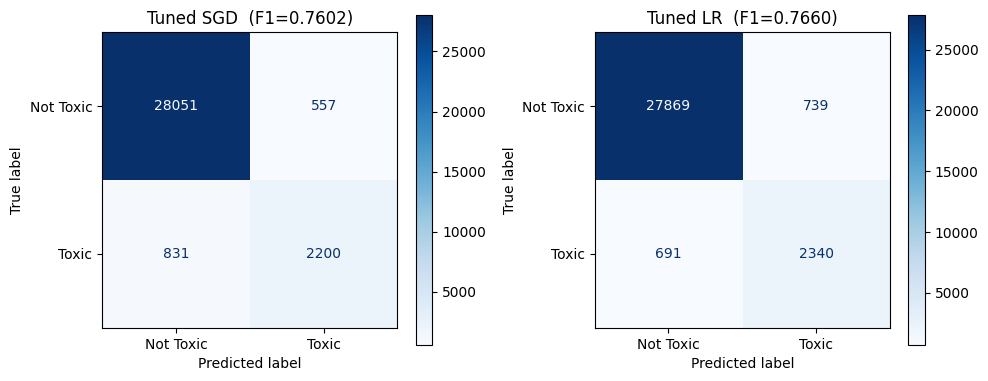

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['Tuned SGD', 'Tuned LR']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, scores[name]['pred'],
        display_labels=['Not Toxic', 'Toxic'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f"{name}  (F1={scores[name]['f1']:.4f})")
plt.tight_layout()
plt.show()


In [43]:
result_df = pd.DataFrame({
    name: {
        'F1': metrics['f1'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'ROC-AUC': metrics['roc_auc'],
        'Best CV F1': sgd_study.best_value if name == 'Tuned SGD' else lr_study.best_value,
    }
    for name, metrics in scores.items()
}).T.round(4)

print('=== Optuna Model Comparison ===')
print(result_df.to_string())


=== Optuna Model Comparison ===
               F1  Precision  Recall  ROC-AUC  Best CV F1
Tuned SGD  0.7602      0.798  0.7258   0.9597      0.7468
Tuned LR   0.7660      0.760  0.7720   0.9642      0.7711


In [44]:
print('Threshold sweep removed so the Optuna notebook stays model-only and directly comparable to the other tuning notebooks.')


Threshold sweep removed so the Optuna notebook stays model-only and directly comparable to the other tuning notebooks.


In [45]:
best_name = max(scores, key=lambda name: scores[name]['f1'])
best_model = models[best_name]

print(f'Best overall model : {best_name}')
print(f'Test F1            : {scores[best_name]["f1"]:.4f}')


Best overall model : Tuned LR
Test F1            : 0.7660


In [46]:
with open(OPTUNA_WORD_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(word_vec, f)

with open(OPTUNA_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

with open(OPTUNA_BEST_MODEL_PATH, 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved: {OPTUNA_BEST_MODEL_PATH}')
print(f'Saved: {OPTUNA_WORD_VECTORIZER_PATH} / {OPTUNA_SCALER_PATH}')


Saved: optuna_best_model.pkl
Saved: optuna_word_vectorizer.pkl / optuna_scaler.pkl


## 8. Save Model & Artifacts

In [47]:
print('Artifacts were already saved with method-specific names in the previous cell.')


Artifacts were already saved with method-specific names in the previous cell.


## 8. Inference Helper


In [48]:
def predict_toxicity(comment: str) -> dict:
    """Predict whether a comment is toxic using the best Optuna-tuned model."""
    raw = str(comment)
    protected = protect_non_toxic_negations(raw)
    clean = clean_text(protected)

    eng = build_all_engineered_features(raw)[ENG_FEATURE_COLS]

    X_w = word_vec.transform([clean])
    X_e = csr_matrix(scaler.transform(eng.values))
    X = hstack([X_w, X_e], format='csr')

    label = best_model.predict(X)[0]
    prob = best_model.predict_proba(X)[0][1]

    return {'label': 'Toxic' if label == 1 else 'Not Toxic', 'probability': round(prob, 4)}


samples = [
    'You are such an idiot, go fuck yourself!',
    'Thanks for explaining the issue, that really helped!',
    'I do not think this policy is fair to everyone.',
]

for s in samples:
    result = predict_toxicity(s)
    print(f"{result['label']:10s} ({result['probability']:.2%})  ->  {s[:60]}")


Toxic      (100.00%)  ->  You are such an idiot, go fuck yourself!
Not Toxic  (0.35%)  ->  Thanks for explaining the issue, that really helped!
Not Toxic  (1.16%)  ->  I do not think this policy is fair to everyone.
